# Benchmark: Constraint Mode Comparison

Compares the four constraint configurations on the same deformation fields:

| Mode | Flags |
|------|-------|
| **Jacobian only** | default |
| **Jacobian + Shoelace** | `enforce_shoelace=True` |
| **Jacobian + Injectivity** | `enforce_injectivity=True` |
| **All constraints** | both `True` |

Metrics: runtime, L2 error, final min Jdet, SLSQP iterations (outer), and
whether all negative Jacobians were eliminated.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from dvfopt import (
    iterative_serial,
    jacobian_det2D,
    generate_random_dvf,
    scale_dvf,
)
from dvfopt.testcases import SYNTHETIC_CASES, make_deformation, make_random_dvf
from dvfopt.viz import plot_deformations, plot_grid_before_after

## Constraint modes

In [2]:
MODES = {
    "Jacobian only": {"enforce_shoelace": False, "enforce_injectivity": False},
    "Jac + Shoelace": {"enforce_shoelace": True, "enforce_injectivity": False},
    "Jac + Injectivity": {"enforce_shoelace": False, "enforce_injectivity": True},
    "All constraints": {"enforce_shoelace": True, "enforce_injectivity": True},
}

## Helper: run one test case across all modes

In [3]:
def run_case(deformation_i, label, n_runs=1):
    """Run all constraint modes on a single deformation field."""
    phi_init = np.stack([deformation_i[-2, 0], deformation_i[-1, 0]])
    jac_init = jacobian_det2D(phi_init)
    n_neg_init = int((jac_init <= 0).sum())
    H, W = deformation_i.shape[-2:]

    print(f"\n{'='*80}")
    print(f"  {label}  |  {H}x{W}  |  Initial neg-Jdet: {n_neg_init}")
    print(f"{'='*80}")

    results = {}
    for mode_name, flags in MODES.items():
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            phi = iterative_serial(
                deformation_i.copy(), verbose=0, **flags
            )
            times.append(time.perf_counter() - t0)

        jac_final = jacobian_det2D(phi)
        final_neg = int((jac_final <= 0).sum())
        final_min = float(jac_final.min())
        l2_err = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
        avg_t = np.mean(times)

        results[mode_name] = {
            "time": avg_t,
            "final_neg": final_neg,
            "final_min": final_min,
            "l2_err": l2_err,
            "phi": phi,
        }

        status = "OK" if final_neg == 0 else "WARN"
        print(f"  {mode_name:<20s}  {avg_t:8.2f}s  "
              f"neg={final_neg:3d}  min_jdet={final_min:+.6f}  "
              f"L2={l2_err:.4f}  [{status}]")

    # Grid visualisations — one before/after grid plot per mode
    for mode_name, res in results.items():
        plot_grid_before_after(deformation_i, res["phi"], title=f"{label} — {mode_name}")

    return results

---
## Test Cases


  Case 1a — 10×10 crossing points  |  10x10  |  Initial neg-Jdet: 9
  Jacobian only             0.04s  neg=  0  min_jdet=+0.010000  L2=2.2705  [OK]
  Jac + Shoelace            0.05s  neg=  0  min_jdet=+0.010000  L2=3.0050  [OK]
  Jac + Injectivity         0.01s  neg=  0  min_jdet=+0.010000  L2=3.0054  [OK]
  All constraints           0.02s  neg=  0  min_jdet=+0.010000  L2=3.0054  [OK]


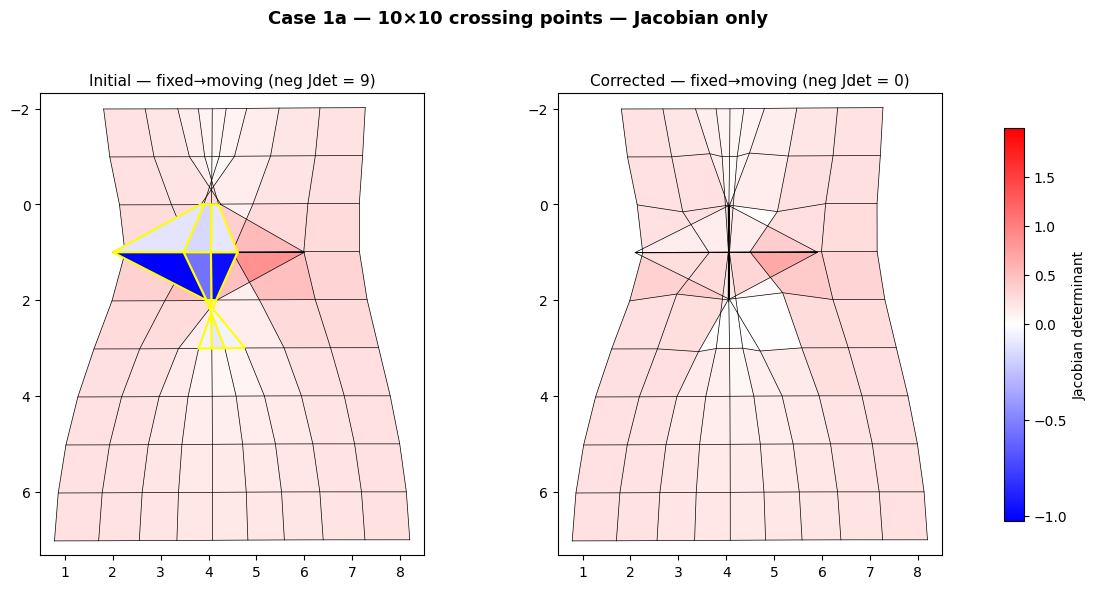

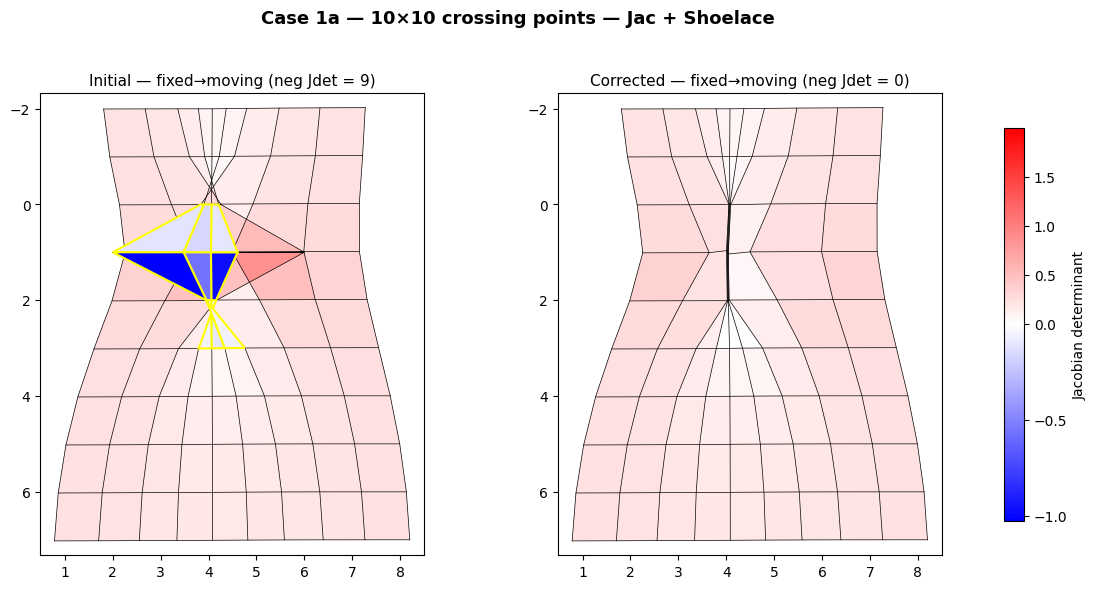

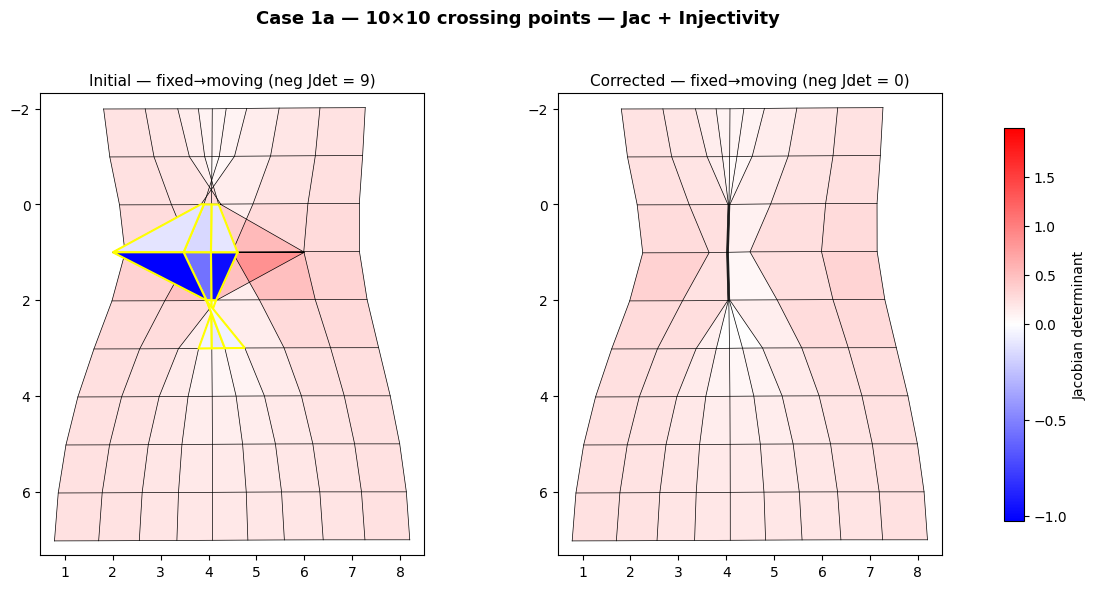

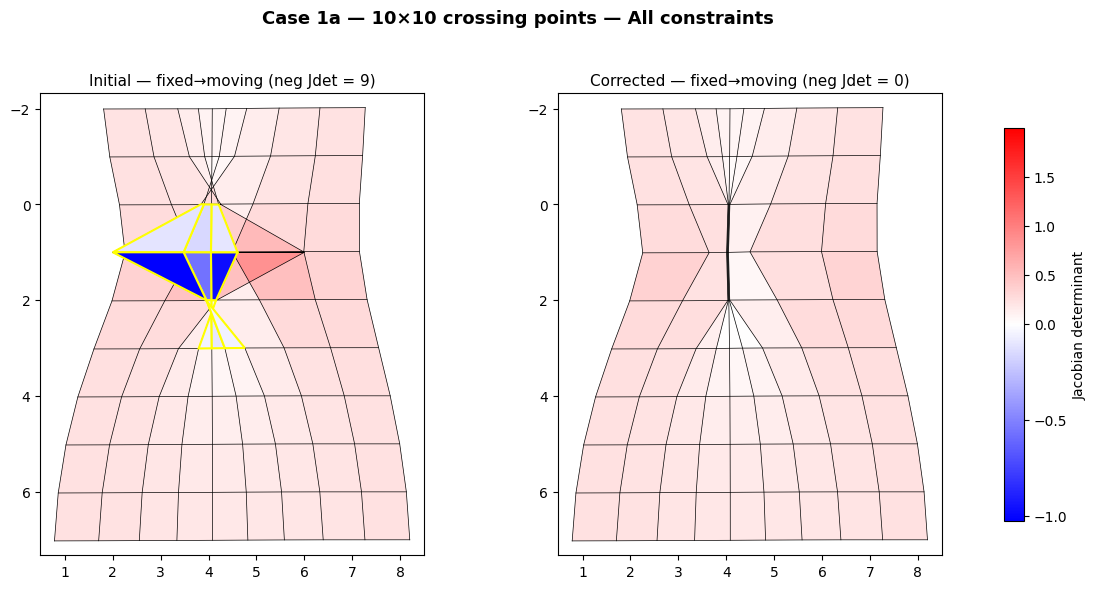


  Case 1c — 20×40 edges  |  20x40  |  Initial neg-Jdet: 33
  Jacobian only             0.59s  neg=  0  min_jdet=+0.009999  L2=3.2940  [OK]
  Jac + Shoelace            0.60s  neg=  0  min_jdet=+0.010000  L2=4.0833  [OK]
  Jac + Injectivity         0.38s  neg=  0  min_jdet=+0.010000  L2=4.6408  [OK]
  All constraints           0.68s  neg=  0  min_jdet=+0.010000  L2=5.0949  [OK]


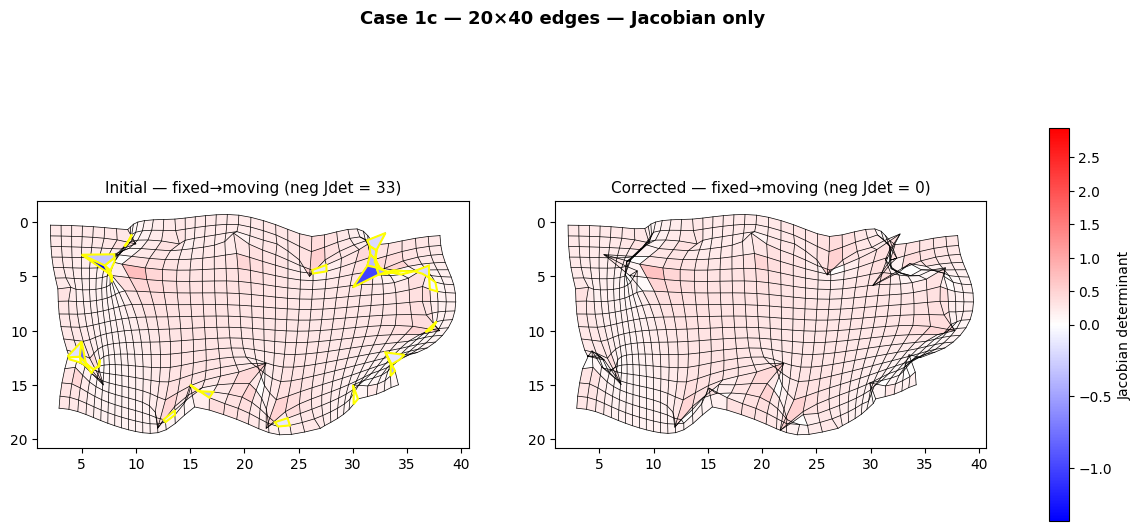

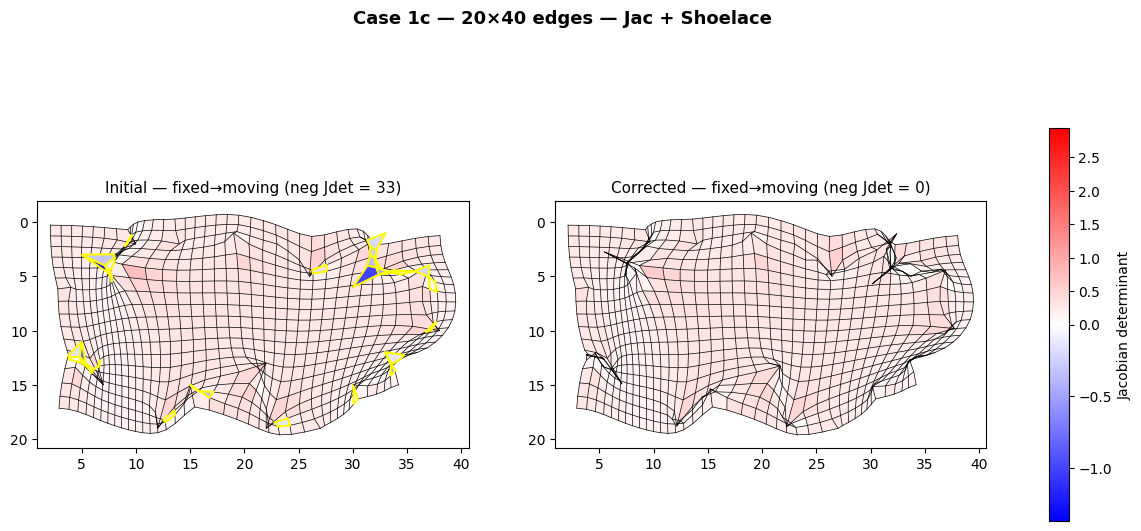

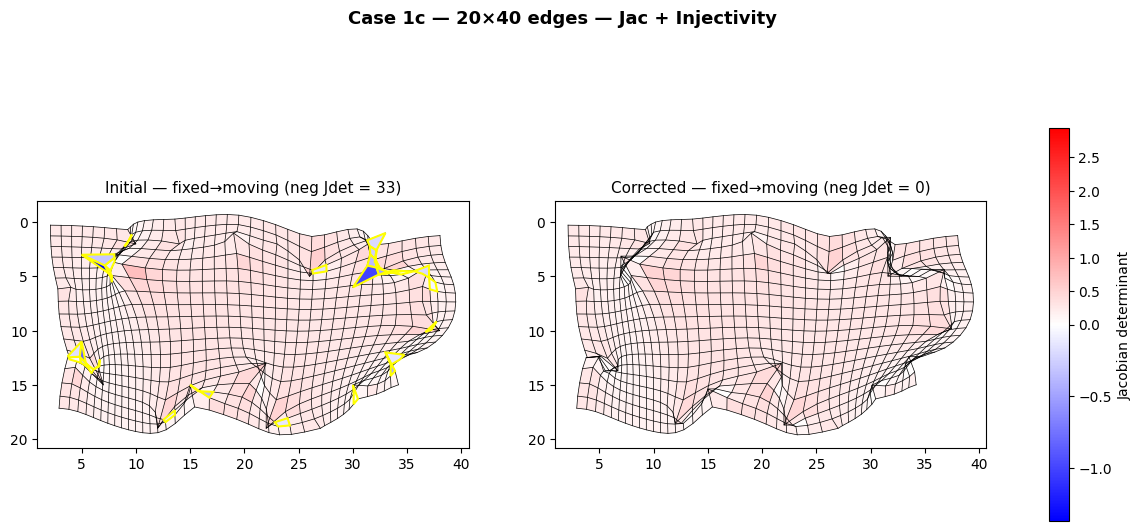

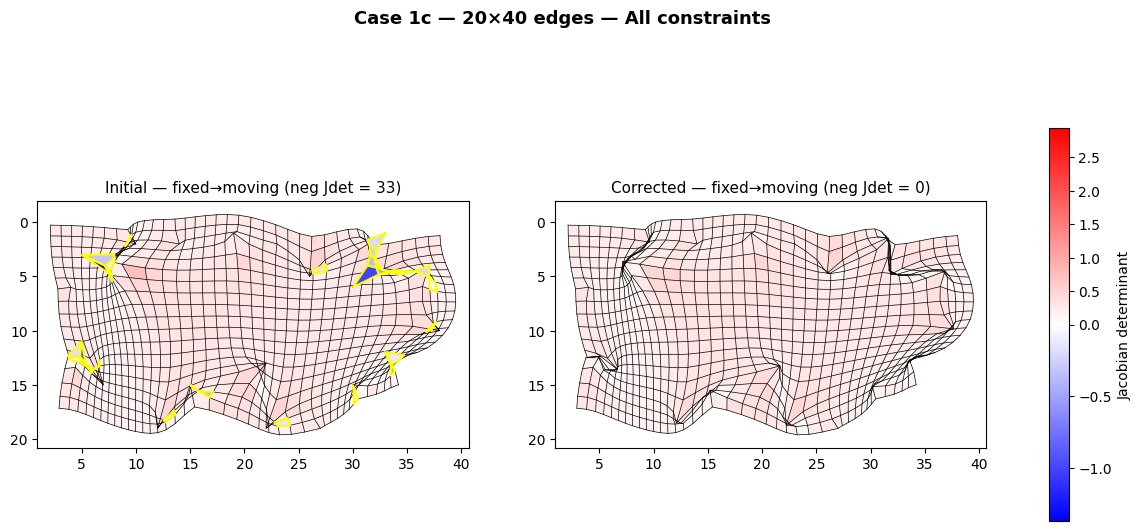


  Case 3d — 20×20 crossing points  |  20x20  |  Initial neg-Jdet: 30
  Jacobian only             0.34s  neg=  0  min_jdet=+0.010000  L2=7.5266  [OK]
  Jac + Shoelace            0.53s  neg=  0  min_jdet=+0.010000  L2=6.9054  [OK]
  Jac + Injectivity         0.09s  neg=  0  min_jdet=+0.009999  L2=7.5605  [OK]
  All constraints           0.19s  neg=  0  min_jdet=+0.009999  L2=7.5594  [OK]


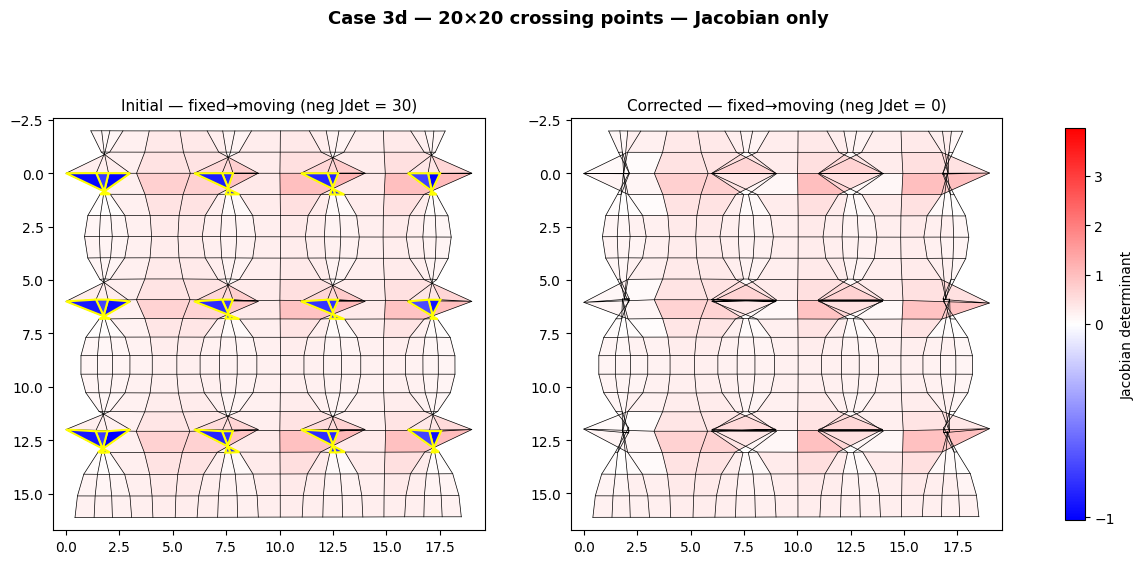

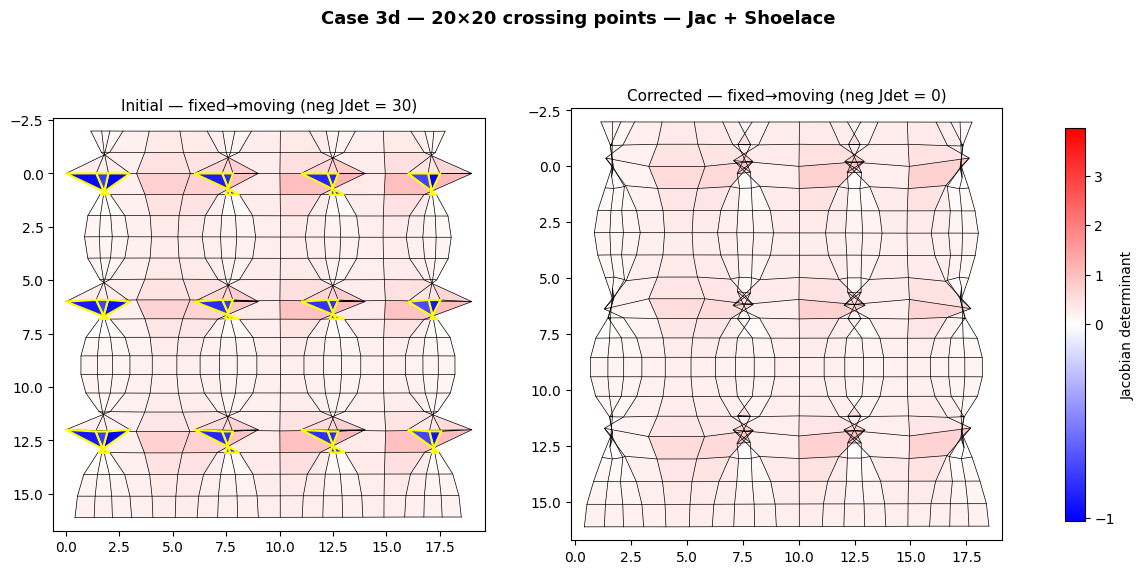

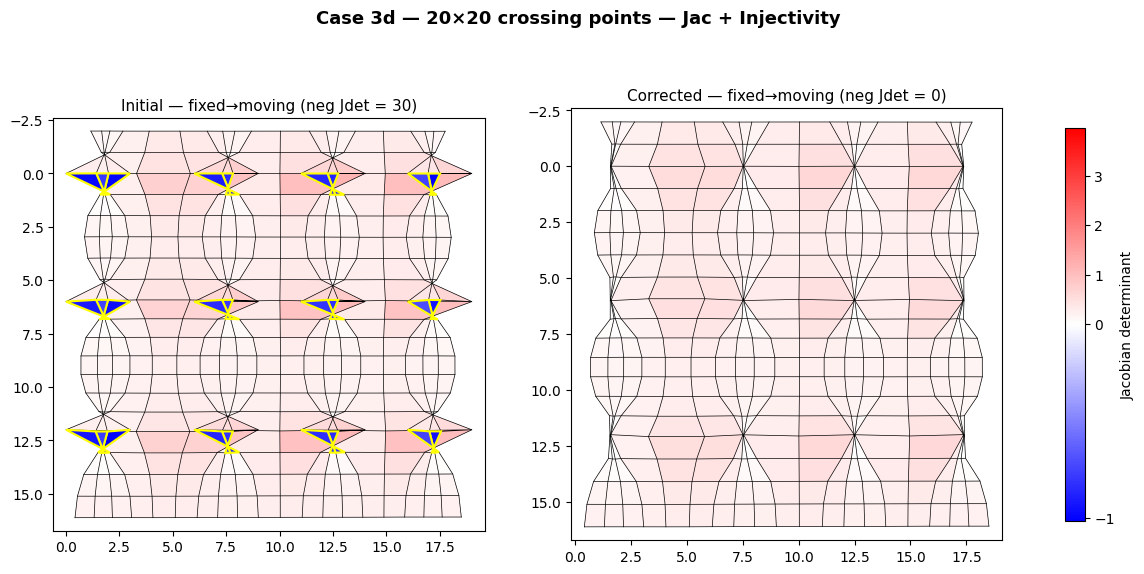

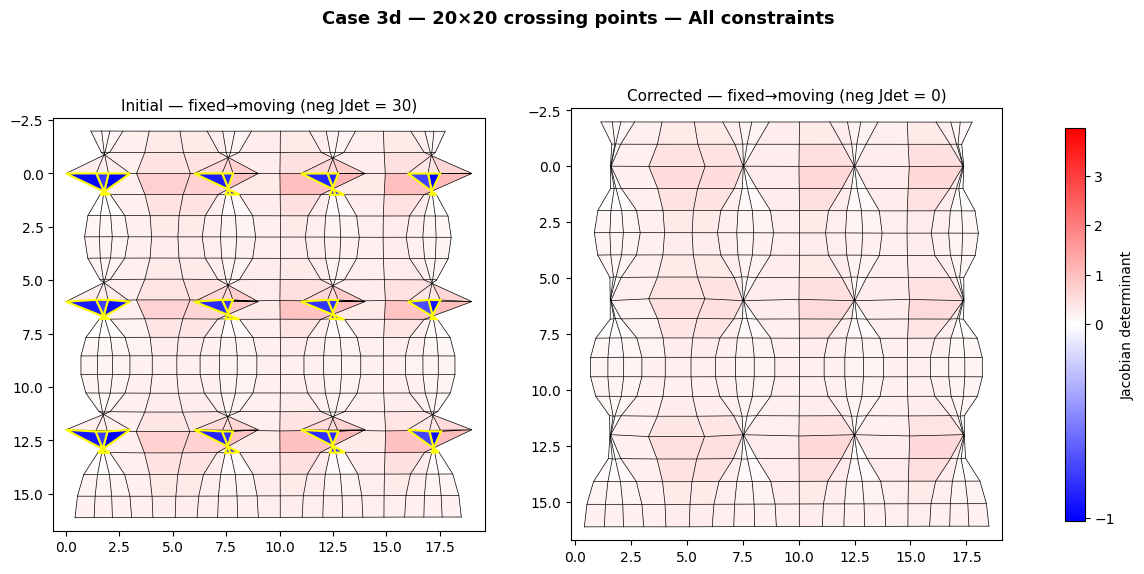

In [4]:
all_results = {}

# --- Synthetic correspondence cases ---
for key in ["01a_10x10_crossing", "01c_20x40_edges", "03d_20x20_crossing"]:
    deformation, ms, fs = make_deformation(key)
    title = SYNTHETIC_CASES[key]["title"]
    all_results[title] = run_case(deformation, title)


  Case 1e — 20×20 spirals  |  20x20  |  Initial neg-Jdet: 189
  Jacobian only            15.60s  neg=  0  min_jdet=+0.010000  L2=37.3513  [OK]
  Jac + Shoelace           51.02s  neg=  0  min_jdet=+0.010000  L2=40.6547  [OK]
  Jac + Injectivity        83.58s  neg=  0  min_jdet=+0.010000  L2=84.9687  [OK]
  All constraints         167.65s  neg=  0  min_jdet=+0.010000  L2=85.7481  [OK]


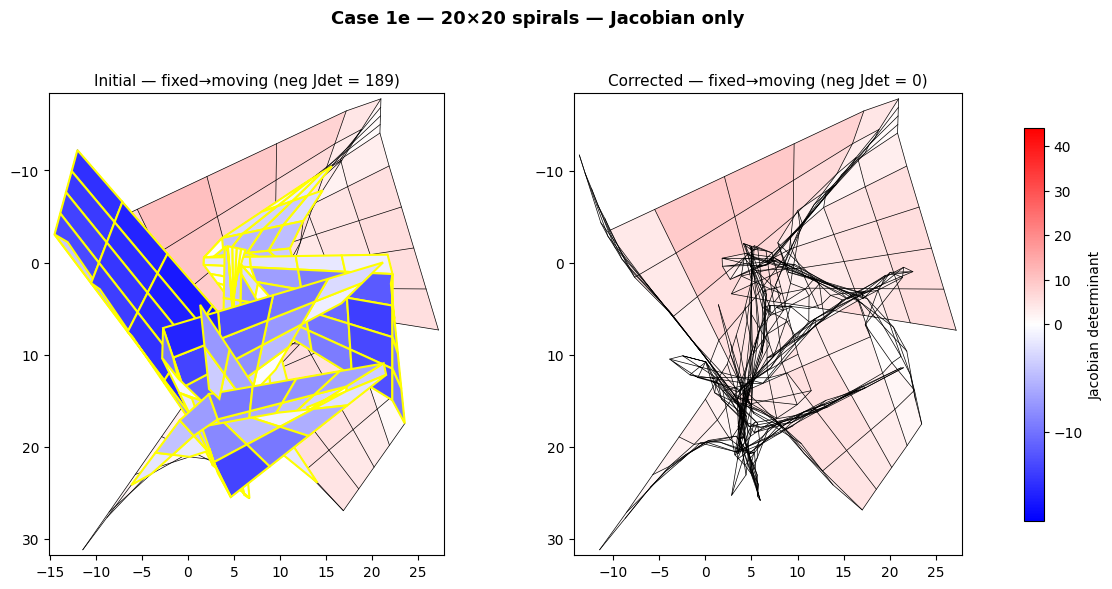

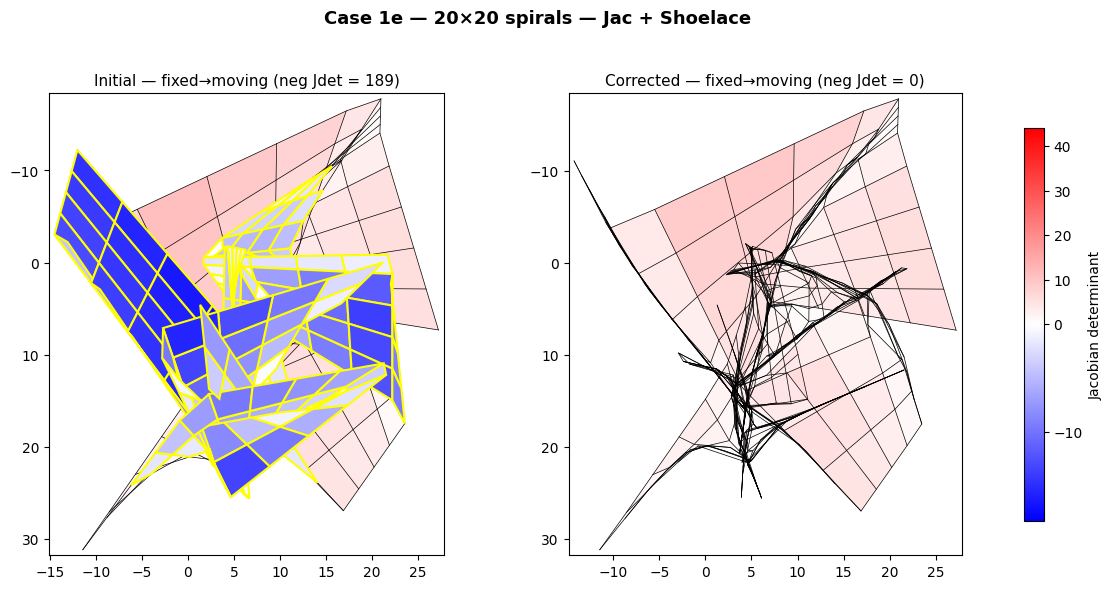

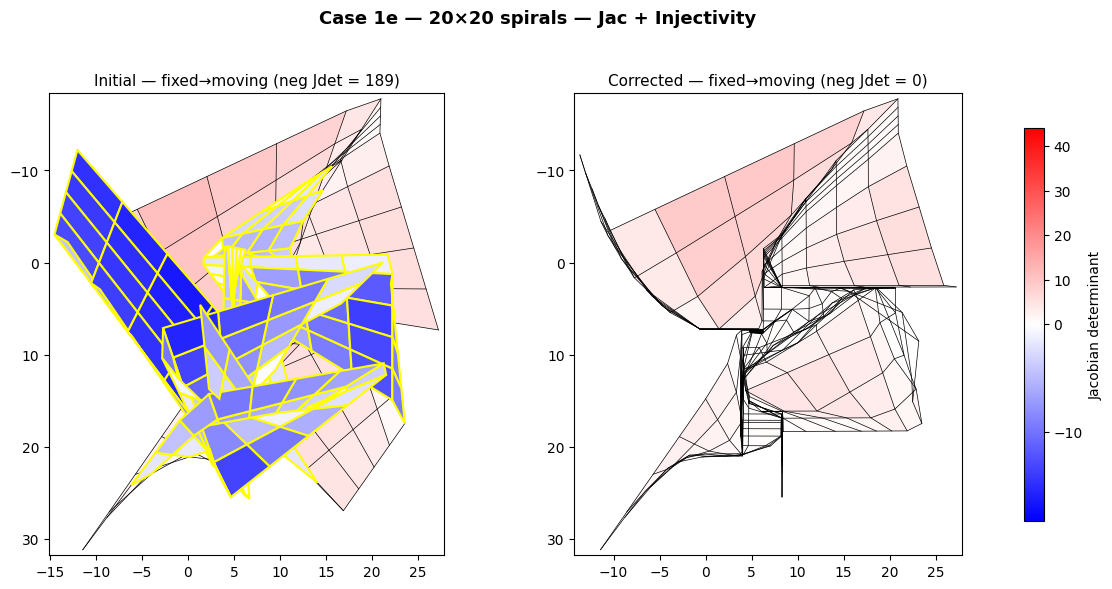

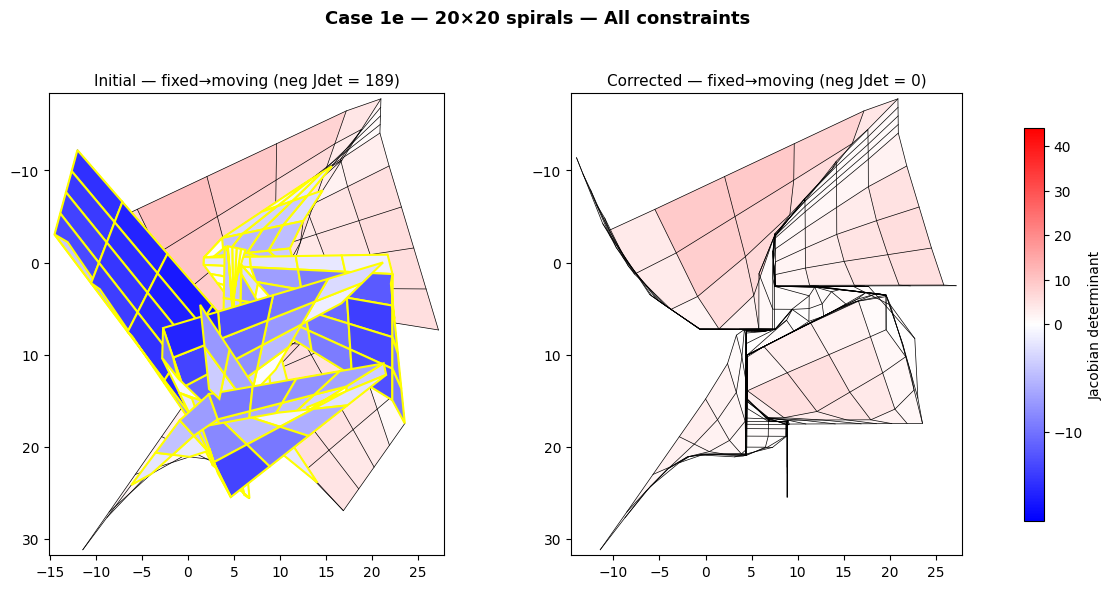


  Case 1f — 20×20 random seed 42  |  20x20  |  Initial neg-Jdet: 148
  Jacobian only             6.62s  neg=  0  min_jdet=+0.010000  L2=14.3732  [OK]
  Jac + Shoelace           25.71s  neg=  0  min_jdet=+0.010000  L2=20.4718  [OK]


In [ ]:
# --- Random DVF cases ---
for key in ["01e_20x20_random_spirals", "01f_20x20_random_seed_42"]:
    deformation = make_random_dvf(key)
    from dvfopt.testcases import RANDOM_DVF_CASES
    title = RANDOM_DVF_CASES[key]["title"]
    all_results[title] = run_case(deformation, title)

In [ ]:
# --- Real-data slice (if available) ---
import os
real_path = "../data/test_cases/02b_64x91_slice200.npy"
if os.path.exists(real_path):
    deformation = np.load(real_path)
    all_results["Real 64x91"] = run_case(deformation, "Real 64x91 slice 200")
else:
    print(f"Skipping real data — {real_path} not found")

---
## Summary Table

In [ ]:
mode_names = list(MODES.keys())

print(f"{'Test Case':<28s}", end="")
for m in mode_names:
    print(f"  {m:>20s}", end="")
print()
print("-" * (28 + 22 * len(mode_names)))

for label, results in all_results.items():
    # Time row
    print(f"{label:<28s}", end="")
    for m in mode_names:
        r = results[m]
        print(f"  {r['time']:>17.2f}s  ", end="")
    print("  (time)")

    # L2 row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        print(f"  {r['l2_err']:>18.4f} ", end="")
    print("  (L2)")

    # Min Jdet row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        print(f"  {r['final_min']:>+18.6f}", end="")
    print("  (min Jdet)")
    print()

## Plots

In [ ]:
# --- Bar chart: runtime by mode ---
case_labels = list(all_results.keys())
x = np.arange(len(case_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(mode_names):
    times = [all_results[c][m]["time"] for c in case_labels]
    ax.bar(x + i * width, times, width, label=m)

ax.set_ylabel("Time (s)")
ax.set_title("Runtime by Constraint Mode")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(case_labels, rotation=25, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Bar chart: L2 error by mode ---
fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(mode_names):
    l2s = [all_results[c][m]["l2_err"] for c in case_labels]
    ax.bar(x + i * width, l2s, width, label=m)

ax.set_ylabel("L2 Error")
ax.set_title("L2 Deviation by Constraint Mode")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(case_labels, rotation=25, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Scatter: runtime vs L2 (Pareto front) ---
fig, ax = plt.subplots(figsize=(8, 6))
markers = ["o", "s", "^", "D"]

for i, m in enumerate(mode_names):
    times = [all_results[c][m]["time"] for c in case_labels]
    l2s = [all_results[c][m]["l2_err"] for c in case_labels]
    ax.scatter(times, l2s, marker=markers[i], s=80, label=m, zorder=3)

ax.set_xlabel("Time (s)")
ax.set_ylabel("L2 Error")
ax.set_title("Runtime vs L2 Error — Constraint Modes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Heatmap: min Jdet by test case x mode ---
min_jdet_matrix = np.array([
    [all_results[c][m]["final_min"] for m in mode_names]
    for c in case_labels
])

fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(case_labels))))
im = ax.imshow(min_jdet_matrix, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=25, ha="right")
ax.set_yticks(range(len(case_labels)))
ax.set_yticklabels(case_labels, fontsize=9)
for i in range(len(case_labels)):
    for j in range(len(mode_names)):
        val = min_jdet_matrix[i, j]
        color = "white" if val < 0 else "black"
        ax.text(j, i, f"{val:+.4f}", ha="center", va="center", fontsize=8, color=color)
fig.colorbar(im, ax=ax, label="Min Jacobian determinant")
ax.set_title("Final Min Jdet -- Test Case x Constraint Mode")
plt.tight_layout()
plt.show()

In [ ]:
# --- Remaining neg-Jdet pixels by mode (convergence success) ---
neg_matrix = np.array([
    [all_results[c][m]["final_neg"] for m in mode_names]
    for c in case_labels
])

fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(case_labels))))
cmap = plt.cm.colors.ListedColormap(["#2ecc71", "#e74c3c"])
bounds = [-0.5, 0.5, neg_matrix.max() + 0.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(neg_matrix, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=25, ha="right")
ax.set_yticks(range(len(case_labels)))
ax.set_yticklabels(case_labels, fontsize=9)
for i in range(len(case_labels)):
    for j in range(len(mode_names)):
        val = neg_matrix[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10,
                fontweight="bold", color="white")
ax.set_title("Remaining Neg-Jdet Pixels (green=0, red=failed)")
plt.tight_layout()
plt.show()

In [ ]:
# --- Runtime overhead relative to Jacobian-only baseline ---
baseline_mode = "Jacobian only"
other_modes = [m for m in mode_names if m != baseline_mode]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(case_labels))
width = 0.25

for i, m in enumerate(other_modes):
    overhead = []
    for c in case_labels:
        base_t = all_results[c][baseline_mode]["time"]
        mode_t = all_results[c][m]["time"]
        overhead.append(mode_t / base_t if base_t > 0 else 1.0)
    ax.bar(x + i * width, overhead, width, label=m)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Baseline (Jac only)")
ax.set_xticks(x + width)
ax.set_xticklabels(case_labels, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Runtime multiplier vs Jacobian-only")
ax.set_title("Constraint Overhead (1.0 = same as Jacobian-only)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()